# GNSS station list ↔ station catalog: quick DEA notebook

This notebook does three things:
1. Reads a `.txt` file containing a list of station names (one per line).
2. Reads a station catalog `.csv`  with columns `id,name,lat,lon,elev_m,depth_to_slab`.
3. Lets you subset (a) by name list and (b) by a geographic bounding box, and visualize results.

It’s intentionally simple and dependency-light (pandas + matplotlib).

In [1]:
# --- Imports ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140


## 1) Point to your input files

Put your files somewhere relative to this notebook (or change the paths below).

In [2]:
# --- Paths (edit these) ---
TXT_PATH = Path("./resources/pnw_stations.txt")      # one station name per line
CSV_PATH = Path("./resources/cascadia_station_info.csv") # catalog, no header (see next cell)

assert TXT_PATH.exists(), f"Missing: {TXT_PATH.resolve()}"
assert CSV_PATH.exists(), f"Missing: {CSV_PATH.resolve()}"
print("OK:", TXT_PATH, CSV_PATH)


OK: resources\pnw_stations.txt resources\cascadia_station_info.csv


## 2) Load the name list (.txt)

We strip whitespace, ignore blank lines, and de-duplicate while preserving order.

In [3]:
def read_station_list(txt_path: Path) -> list[str]:
    names = []
    seen = set()
    for raw in txt_path.read_text(encoding="utf-8").splitlines():
        s = raw.strip()
        if not s:
            continue
        if s not in seen:
            names.append(s)
            seen.add(s)
    return names

station_list = read_station_list(TXT_PATH)
print(f"Loaded {len(station_list)} station names from {TXT_PATH}:")
station_list[:20]


Loaded 1124 station names from resources\pnw_stations.txt:


['34A1',
 '34A2',
 '34A3',
 '34A4',
 '34NO',
 '34SO',
 'ABBY',
 'ABOT',
 'ABRN',
 'ADLL',
 'AGNS',
 'AL2H',
 'ALB4',
 'ALBH',
 'ANAT',
 'ANTB',
 'ANTE',
 'ANTV',
 'ARLI',
 'ARLN']

## 3) Load the station catalog (.csv)

Your catalog sample looks like:
`id,name,lat,lon,elev_m,score`

If your real file has headers, set `has_header=True` in the loader below.

In [5]:
CAT_COLS = ["id", "name", "lat", "lon", "elev_m", "depth"]

def read_station_catalog(csv_path: Path, has_header: bool = False) -> pd.DataFrame:
    if has_header:
        df = pd.read_csv(csv_path)
    else:
        df = pd.read_csv(csv_path, header=None, names=CAT_COLS)

    # Basic cleaning / typing
    df["name"] = df["name"].astype(str).str.strip()
    for c in ["lat", "lon", "elev_m", "depth"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")

    # Drop rows missing essential coords
    df = df.dropna(subset=["lat", "lon"]).reset_index(drop=True)
    return df

cat = read_station_catalog(CSV_PATH, has_header=False)
cat.head()


,id,name,lat,lon,elev_m,depth
0,532,34A1,41.838658,-119.653981,1907.677230,100.0
1,533,34A2,41.853118,-119.607364,1862.779433,100.0
2,534,34A3,41.850735,-119.577144,1831.947409,100.0
3,535,34A4,41.866602,-119.494825,1708.215726,100.0
4,536,34NO,41.929142,-119.708565,1768.973118,100.0


### Quick sanity checks

In [6]:
print("Catalog rows:", len(cat))
print("Unique station names:", cat["name"].nunique())
print("Lat range:", (cat["lat"].min(), cat["lat"].max()))
print("Lon range:", (cat["lon"].min(), cat["lon"].max()))


Catalog rows: 1125
Unique station names: 1125
Lat range: (np.float64(39.014330562), np.float64(50.989155872))
Lon range: (np.float64(-128.134996932), np.float64(-115.064974174))


## 4) Subset by your `.txt` station list

This keeps catalog rows whose `name` is in the text list. We also report names that were requested but missing in the catalog.

In [7]:
wanted = set(station_list)

in_list = cat[cat["name"].isin(wanted)].copy().reset_index(drop=True)
missing = sorted(wanted - set(cat["name"].unique()))

print(f"Matched {len(in_list)} catalog rows from {len(station_list)} requested names.")
if missing:
    print(f"Missing {len(missing)} names (present in TXT, not in CSV):")
    print(missing[:50], "..." if len(missing) > 50 else "")
else:
    print("No missing names 🎯")

in_list


Matched 1124 catalog rows from 1124 requested names.
No missing names 🎯


,id,name,lat,lon,elev_m,depth
0,532,34A1,41.838658,-119.653981,1907.677230,100.000000
1,533,34A2,41.853118,-119.607364,1862.779433,100.000000
2,534,34A3,41.850735,-119.577144,1831.947409,100.000000
3,535,34A4,41.866602,-119.494825,1708.215726,100.000000
4,536,34NO,41.929142,-119.708565,1768.973118,100.000000
...,...,...,...,...,...,...
1119,20142,YELM,46.948717,-122.605735,81.993392,47.067462
1120,20167,YOCR,45.379102,-121.743553,1884.269527,71.691628
1121,20171,YONC,43.634111,-123.298301,86.491947,39.870046
1122,20339,ZOLE,39.421671,-119.753358,1357.312549,100.000000


## 5) Plot stations on a simple lat/lon scatter

This is not a true map projection (just lon vs lat), but it’s fast and good for eyeballing extents.

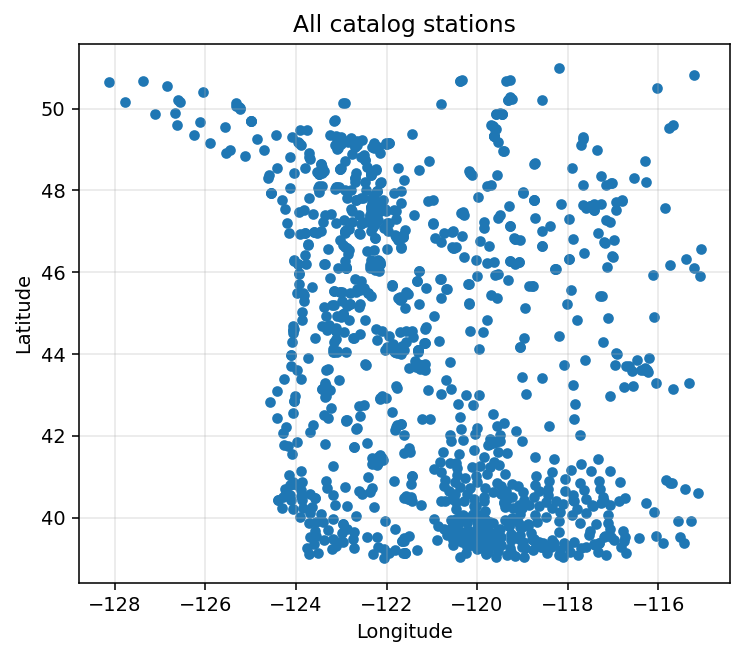

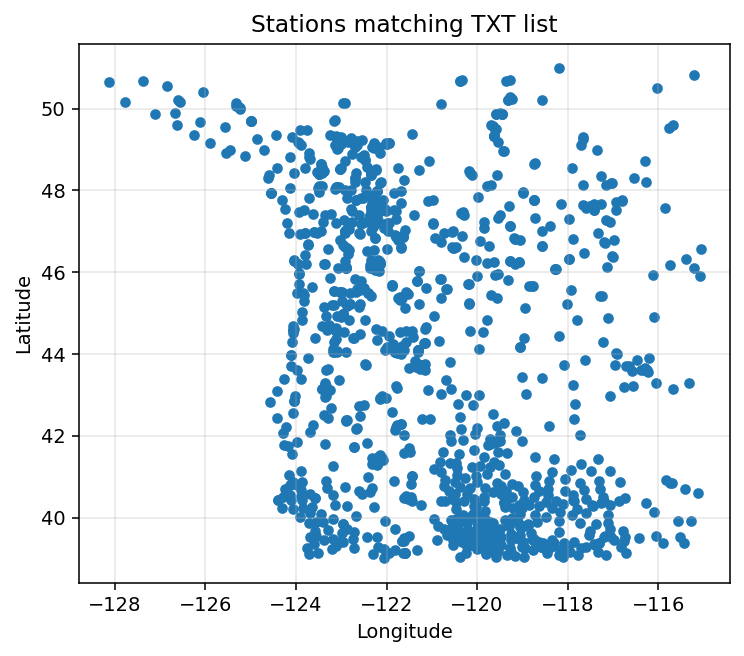

In [8]:
def plot_stations(df: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df["lon"], df["lat"], s=20)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # label if few points
    if len(df) <= 30:
        for _, r in df.iterrows():
            ax.annotate(r["name"], (r["lon"], r["lat"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    plt.show()

plot_stations(cat, "All catalog stations")
plot_stations(in_list, "Stations matching TXT list")


## 6) Geographic subset: bounding box

Define a bounding box (min/max lat/lon) and filter either the full catalog or the TXT-matched subset.

Tip: For Pacific Northwest-ish data, a starting guess might be:
- lat: 40–50
- lon: -125–-116

In [9]:
# --- Bounding box  ---
MIN_LAT, MAX_LAT = 39.5, 51.5
MIN_LON, MAX_LON = -130.0, -121.0

def subset_bbox(df: pd.DataFrame, min_lat: float, max_lat: float, min_lon: float, max_lon: float) -> pd.DataFrame:
    m = (
        (df["lat"] >= min_lat) & (df["lat"] <= max_lat) &
        (df["lon"] >= min_lon) & (df["lon"] <= max_lon)
    )
    return df[m].copy().reset_index(drop=True)

cat_bbox = subset_bbox(cat, MIN_LAT, MAX_LAT, MIN_LON, MAX_LON)
in_list_bbox = subset_bbox(in_list, MIN_LAT, MAX_LAT, MIN_LON, MAX_LON)

print("Catalog in bbox:", len(cat_bbox))
print("TXT-matched in bbox:", len(in_list_bbox))
cat_bbox.head()


Catalog in bbox: 570
TXT-matched in bbox: 569


,id,name,lat,lon,elev_m,depth
0,686,ABBY,49.072141,-122.197803,195.280394,82.188029
1,731,ABOT,49.029436,-122.266570,-4.009165,78.927993
2,915,AGNS,42.552765,-124.059114,51.368366,20.147110
3,987,AL2H,48.389780,-123.487472,31.750396,37.481953
4,1021,ALB4,48.389740,-123.487687,30.890637,37.479202


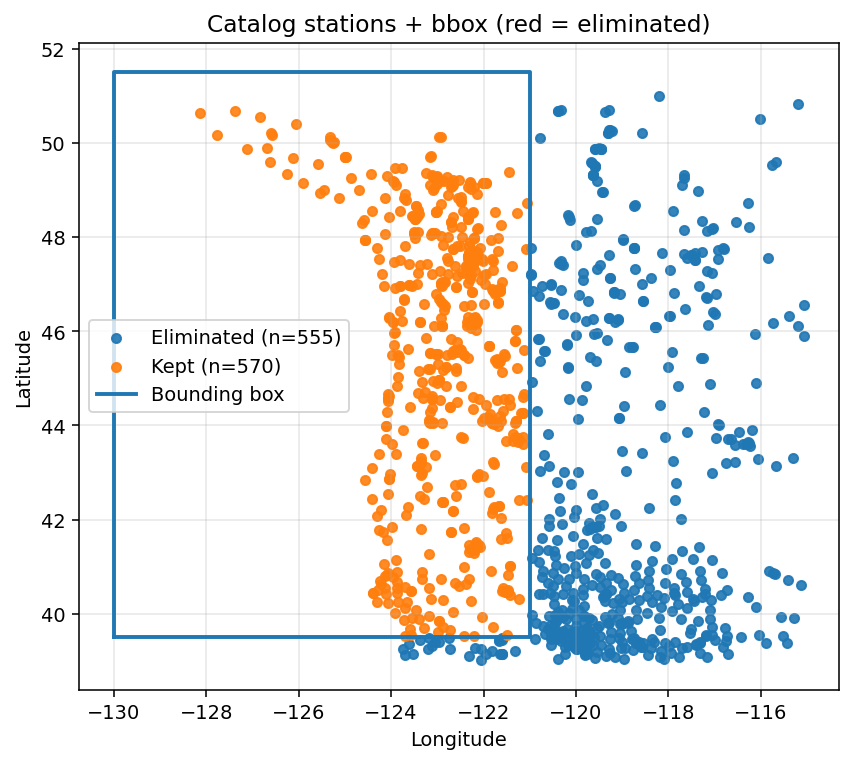

In [11]:
# --- Plot all stations + bbox, eliminated in red ---

def plot_bbox_elimination(df: pd.DataFrame,
                          min_lat: float, max_lat: float,
                          min_lon: float, max_lon: float,
                          title: str = "Catalog stations + bbox (red = eliminated)",
                          label_if_n_leq: int = 30):
    inside = (
        (df["lat"] >= min_lat) & (df["lat"] <= max_lat) &
        (df["lon"] >= min_lon) & (df["lon"] <= max_lon)
    )

    kept = df[inside].copy()
    elim = df[~inside].copy()

    fig, ax = plt.subplots(figsize=(7, 6))

    # plot eliminated first so kept sits "on top"
    ax.scatter(elim["lon"], elim["lat"], s=22, alpha=0.9, label=f"Eliminated (n={len(elim)})")
    ax.scatter(kept["lon"], kept["lat"], s=22, alpha=0.9, label=f"Kept (n={len(kept)})")

    # draw bounding box
    ax.plot(
        [min_lon, max_lon, max_lon, min_lon, min_lon],
        [min_lat, min_lat, max_lat, max_lat, min_lat],
        linewidth=2,
        label="Bounding box"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    # optional labels
    if len(df) <= label_if_n_leq:
        for _, r in df.iterrows():
            ax.annotate(r["name"], (r["lon"], r["lat"]),
                        fontsize=8, xytext=(3, 3), textcoords="offset points")

    plt.show()

plot_bbox_elimination(cat, MIN_LAT, MAX_LAT, MIN_LON, MAX_LON)


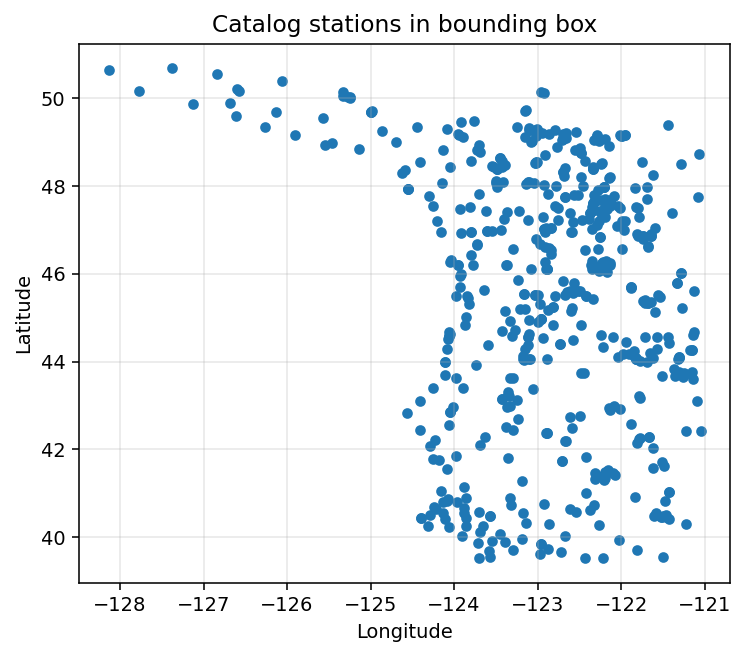

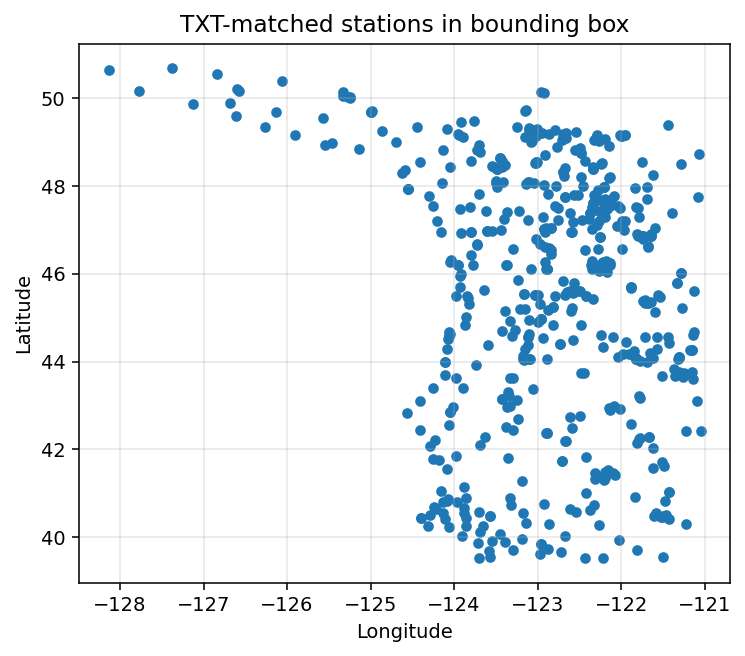

In [10]:
plot_stations(cat_bbox, "Catalog stations in bounding box")
plot_stations(in_list_bbox, "TXT-matched stations in bounding box")


## 7) Export subsets

This writes CSV files you can use elsewhere (e.g., for downstream GNSS preprocessing).

In [12]:
OUT_DIR = Path("resources")
OUT_DIR.mkdir(exist_ok=True)

cat_bbox_path = OUT_DIR / "catalog_subset_bbox.csv"
in_list_bbox_path = OUT_DIR / "txtmatched_subset_bbox.csv"

cat_bbox.to_csv(cat_bbox_path, index=False)
in_list_bbox.to_csv(in_list_bbox_path, index=False)

print("Wrote:")
print(" -", cat_bbox_path)
print(" -", in_list_bbox_path)


Wrote:
 - resources\catalog_subset_bbox.csv
 - resources\txtmatched_subset_bbox.csv
